<a href="https://colab.research.google.com/github/RajShahi26/real-time-hand-gesture-recognition/blob/main/vision_self_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print("Path to dataset files:", path)

100%|██████████| 2.13G/2.13G [00:56<00:00, 40.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [ ]:
import os
print(os.listdir(path))

['leapgestrecog', 'leapGestRecog']


In [ ]:
import cv2
import matplotlib.pyplot as plt


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
dataset_path = path + "/leapGestRecog"

In [ ]:
dataset_path=os.path.join(path,"leapGestRecog")
print(os.listdir(dataset_path))

['07', '05', '06', '02', '04', '00', '08', '09', '03', '01']


In [ ]:
subject_path = os.path.join(dataset_path, "00")
print(os.listdir(subject_path))

['02_l', '04_fist_moved', '09_c', '10_down', '06_index', '08_palm_moved', '07_ok', '05_thumb', '01_palm', '03_fist']


In [ ]:
gesture = os.listdir(subject_path)[0]

print(gesture)

02_l


In [ ]:
gesture_path = os.path.join(
    subject_path,
    gesture
)

print(gesture_path)

/kaggle/input/leapgestrecog/leapGestRecog/00/02_l


In [ ]:
print(os.listdir(gesture_path)[:5])

['frame_00_02_0178.png', 'frame_00_02_0112.png', 'frame_00_02_0056.png', 'frame_00_02_0193.png', 'frame_00_02_0083.png']


In [ ]:
image_name = os.listdir(gesture_path)[0]

print(image_name)

frame_00_02_0178.png


In [ ]:
image_path = os.path.join(
    gesture_path,
    image_name
)

print(image_path)

/kaggle/input/leapgestrecog/leapGestRecog/00/02_l/frame_00_02_0178.png


In [ ]:
img = cv2.imread(image_path)

print(type(img))

<class 'numpy.ndarray'>


In [ ]:
print(img.shape)

(240, 640, 3)


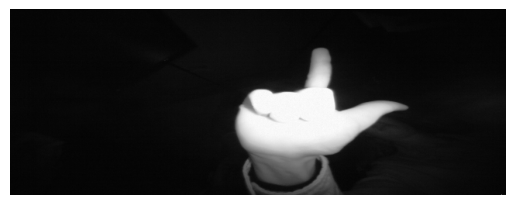

In [ ]:


img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
from collections import defaultdict

gesture_count = defaultdict(int)

for subject in os.listdir(dataset_path):

    subject_path = os.path.join(
        dataset_path,
        subject
    )

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(
            subject_path,
            gesture
        )

        gesture_count[gesture] += len(
            os.listdir(gesture_path)
        )

for gesture, count in gesture_count.items():
    print(f"{gesture}: {count}")

02_l: 2000
04_fist_moved: 2000
09_c: 2000
10_down: 2000
06_index: 2000
08_palm_moved: 2000
07_ok: 2000
05_thumb: 2000
01_palm: 2000
03_fist: 2000


In [ ]:
#loadin of the image
images = []
labels = []

for subject in os.listdir(dataset_path):

    subject_path = os.path.join(
        dataset_path,
        subject
    )

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(
            subject_path,
            gesture
        )

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(
                gesture_path,
                img_name
            )

            img = cv2.imread(img_path)

            img = cv2.resize(
                img,
                (64, 64)
            )

            images.append(img)

            labels.append(gesture)

print("Done")

Done


In [ ]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(20000, 64, 64, 3)
(20000,)


In [ ]:
print(np.unique(y))

['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [ ]:
print(X[0].shape)
print(y[0])

(64, 64, 3)
02_l


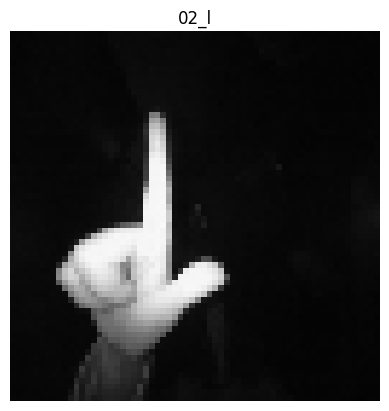

In [ ]:
plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))
plt.title(y[0])
plt.axis("off")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [ ]:
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
for i, label in enumerate(encoder.classes_):
    print(i, "->", label)

0 -> 01_palm
1 -> 02_l
2 -> 03_fist
3 -> 04_fist_moved
4 -> 05_thumb
5 -> 06_index
6 -> 07_ok
7 -> 08_palm_moved
8 -> 09_c
9 -> 10_down


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(16000, 64, 64, 3)
(4000, 64, 64, 3)
(16000,)
(4000,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

 Trainable params: 1,275,722 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8823 - loss: 0.6703 - val_accuracy: 0.9975 - val_loss: 0.0077
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9883 - loss: 0.0401 - val_accuracy: 1.0000 - val_loss: 8.7295e-04
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9867 - loss: 0.0451 - val_accuracy: 0.9987 - val_loss: 0.0033
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9953 - loss: 0.0153 - val_accuracy: 0.9975 - val_loss: 0.0083
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9918 - loss: 0.0368 - val_accuracy: 0.9998 - val_loss: 5.9014e-04
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9973 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 1.2694e-04
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9946 - loss: 0.0273 - val_accuracy: 0.9983 - val_loss: 0.0043
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9966 - loss: 0.0114 - val

In [ ]:
model.save("gesture_model.keras")

In [ ]:
y_pred = model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=encoder.classes_
    )
)

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

print(cm)

[[400   0   0   0   0   0   0   0   0   0]
 [  0 400   0   0   0   0   0   0   0   0]
 [  0   0 400   0   0   0   0   0   0   0]
 [  0   0   0 400   0   0   0   0   0   0]
 [  0   0   0   0 400   0   0   0   0   0]
 [  0   0   0   0   0 400   0   0   0   0]
 [  0   0   0   0   0   0 400   0   0   0]
 [  0   0   0   0   0   0   0 400   0   0]
 [  0   0   0   0   0   0   0   0 400   0]
 [  0   0   0   0   0   0   0   0   0 400]]


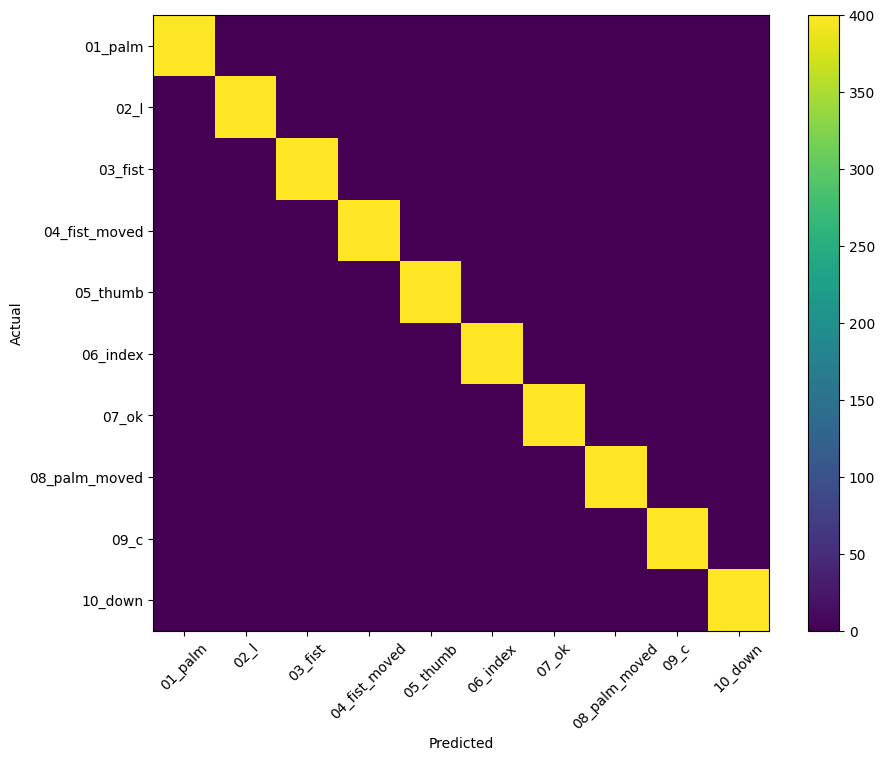

In [ ]:


plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(10),
    encoder.classes_,
    rotation=45
)

plt.yticks(
    range(10),
    encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step


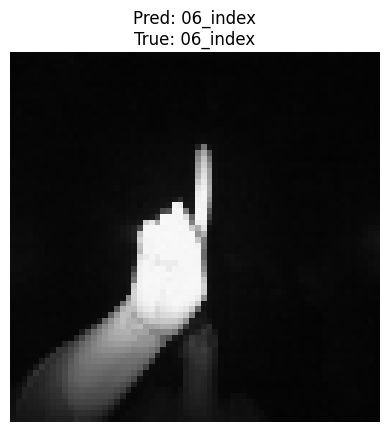

In [ ]:
import random

idx = random.randint(
    0,
    len(X_test)-1
)

img = X_test[idx]

pred = model.predict(
    np.expand_dims(img, axis=0)
)

pred_class = np.argmax(pred)

true_class = y_test[idx]

plt.imshow(img)

plt.title(
    f"Pred: {encoder.classes_[pred_class]}\n"
    f"True: {encoder.classes_[true_class]}"
)

plt.axis("off")

plt.show()

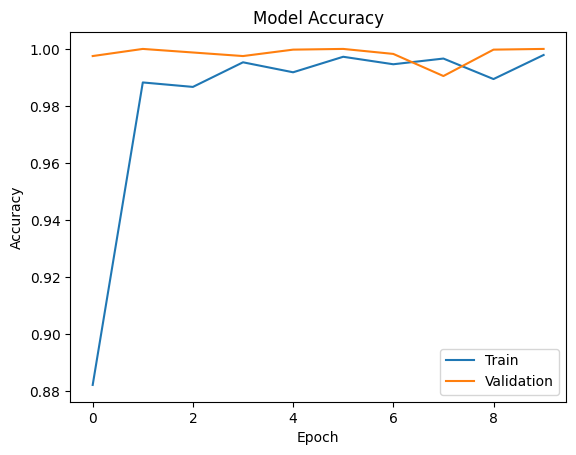

In [ ]:


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

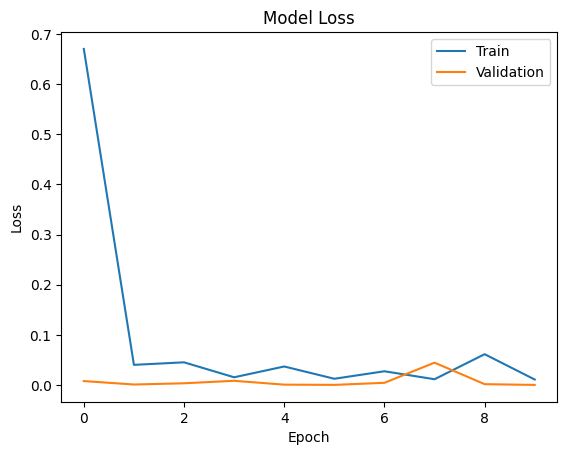

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
model.save("gesture_model.keras")

In [ ]:
!ls /content

gesture_model.keras  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save(
    "/content/drive/MyDrive/gesture_model.keras"
)

Mounted at /content/drive


In [ ]:


print(
    os.path.exists(
        "/content/drive/MyDrive/gesture_model.keras"
    )
)

True


In [ ]:
!ls "/content/drive/MyDrive"

'25AG61R10_SINGLE ACTION Disk harrow'  'reg (4).vcf'
'AG60209 - Class Handout 1-2.pdf'       solidwork
'Colab Notebooks'		        SOLIDWORK_CLASS
'Copy of 2030 agenda for UN SDGs.pdf'  'Untitled video (1).gvid'
 cvGenerate_final.pdf		       'Untitled video.gvid'
 gesture_model.keras


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/gesture_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

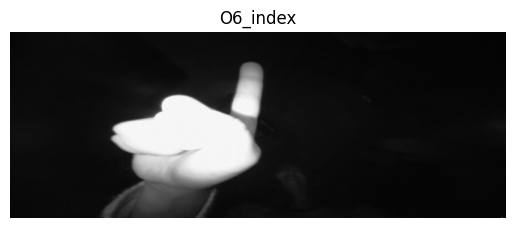

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
import os

gesture = "06_index"

subject = random.choice(os.listdir(dataset_path))
gesture_path = os.path.join(dataset_path, subject, gesture)

img_name = random.choice(os.listdir(gesture_path))
img_path = os.path.join(gesture_path, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img)
plt.title("O6_index")
plt.axis("off")
plt.show()